# Bmad -> Impact-T for `sc_inj`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pytao import Tao
from pmd_beamphysics import FieldMesh
from impact import fieldmaps
import pandas as pd
import numpy as np
from copy import deepcopy
import os

In [3]:
# Nicer plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Bmad 

In [4]:
MODEL = '$LCLS_LATTICE/bmad/models/sc_inj/'

In [5]:
%%time
INIT = f'-init {MODEL}/tao.init -noplot -slice BEGINNING:ENDL0B'
tao = Tao(INIT)
#tao.cmd(f'set beam_init position_file = {P0FILE}')
#tao.cmd('beamon')

CPU times: user 12.5 s, sys: 152 ms, total: 12.7 s
Wall time: 12.7 s


In [6]:
# def ele_info(ele):
#     dat = tao.ele_head(ele)
#     dat.update(tao.ele_gen_attribs(ele))
#     return dat
# 
# def ele_table(match="*"):
#     ix_ele = tao.lat_list(match, "ele.ix_ele", flags="-no_slaves")
#     dat = list(map(ele_info, ix_ele))
#     df = pd.DataFrame(dat, index=ix_ele)
#     df.L.fillna(0, inplace=True)
#     df['s_center'] = df['s'] - df['L']/2
#     df['s_beginning'] = df['s'] - df['L']
#     return  df
# 
# ele_table()

In [7]:
from pytao.util.parameters import tao_parameter_dict
from pmd_beamphysics.interfaces.impact import create_impact_solrf_rfdata

In [8]:
def create_impact_solrf_ele(tao, ele_name, n_coef=None, fieldmap_filename='rfdata666'):
    
    edat = tao.ele_head(ele_name)
    edat.update(tao.ele_gen_attribs(ele_name))
    
    species = tao.branch1(1, 0)['param_particle'].lower()
    if species == 'electron':
        charge_sign = -1
    else:
        raise NotImplementedError(f'{species} not implemented')
    
    key = edat['key'].upper() 
    s = edat['s']
    L = edat['L']
    s_begin = s-L
    s_center = (s + s_begin)/2
    
    
    grid_params = tao.ele_grid_field(ele_name, 1, 'base', as_dict=False)
    phi0_fieldmap = grid_params['phi0_fieldmap'].value
    field_file = grid_params['file'].value    
    freq = edat.get('RF_FREQUENCY', 0)
    
    zmirror=False
    bscale = 0
    escale = 0
    theta0_deg = 0
    phase_fudge_deg = 0
    if key == 'E_GUN':
        zmirror=True

    if key == 'SOLENOID':
        bscale = edat['BS_FIELD']         
    elif key in ('E_GUN', 'LCAVITY'):
        escale = edat['FIELD_AUTOSCALE']
        
        # Phasing
        
        # Get ref_time_start
        ref_time_start = tao.ele_param(ele_name, 'ele.ref_time_start')['ele_ref_time_start']
        phi0_ref = freq*ref_time_start
        
        phi0_list = [edat['PHI0'], edat['PHI0_ERR'], edat['PHI0_AUTOSCALE'], phi0_fieldmap, -phi0_ref]
        phi0_tot = sum(phi0_list) % 1 
        
        theta0_deg = phi0_tot * 360 
    else:
        raise
        
    field_mesh = FieldMesh(field_file)
    fdat = create_impact_solrf_rfdata(field_mesh, n_coef = n_coef, zmirror=zmirror, err_calc=True)
    
    if fdat['Ez_err'] > 1e-3 or fdat['Bz_err'] > 1e-3:
        raise ValueError('Field reconstruction error too large!')
        
        
    # Find zedge
    anchor = grid_params['ele_anchor_pt'].value.upper()
    if anchor == 'BEGINNING':
        zedge = s_begin
    elif anchor == 'CENTER':
        zedge = s_center - L/2
    else:
        raise NotImplementedError(f'{anchor} not implemented')

    # Frequency
    assert np.allclose(freq, field_mesh.frequency), f'{freq} != {field_mesh.frequency}'

    
    fmap = {'info': {'format': 'rfdata', 'filePath': fieldmap_filename},
            'data':fdat['rfdata'],
           }
    
    #return idat
    ele = {'description': f'name:{ele_name}',
     'L': edat['L'],
     'type': 'solrf',
     'zedge': zedge,
     'rf_field_scale': escale,
     'rf_frequency': freq,
     'theta0_deg': theta0_deg,
     'filename': fieldmap_filename,
     'radius': 0.15,
     'x_offset': edat['X_OFFSET'],
     'y_offset': edat['Y_OFFSET'],
     'x_rotation': 0.0,
     'y_rotation': 0.0,
     'z_rotation': 0.0,
     'solenoid_field_scale': bscale,
     'name': ele_name,
     's': s,
          }
    
    return ele.copy(), {fieldmap_filename:fmap}
create_impact_solrf_ele(tao, 'BUN1B', n_coef=30)

({'description': 'name:BUN1B',
  'L': 0.3,
  'type': 'solrf',
  'zedge': 0.6591159999999999,
  'rf_field_scale': 1800000.0,
  'rf_frequency': 1300000000.0,
  'theta0_deg': 216.7685022621053,
  'filename': 'rfdata666',
  'radius': 0.15,
  'x_offset': 0.0,
  'y_offset': 0.0,
  'x_rotation': 0.0,
  'y_rotation': 0.0,
  'z_rotation': 0.0,
  'solenoid_field_scale': 0,
  'name': 'BUN1B',
  's': 0.959116},
 {'rfdata666': {'info': {'format': 'rfdata', 'filePath': 'rfdata666'},
   'data': array([ 5.90000000e+01,  0.00000000e+00,  3.00000000e-01,  3.00000000e-01,
           1.94021367e-17,  1.16536487e-16, -7.94287579e-01,  1.58500193e-16,
          -4.16628241e-01,  4.05389969e-18,  3.21243744e-02, -7.47421873e-18,
          -1.30158958e-03,  3.62835033e-17, -4.14458741e-02,  3.50265064e-17,
           1.42813708e-02,  5.65750246e-17,  1.99647751e-02,  2.72227919e-16,
           1.13411888e-03,  1.03449828e-16,  1.20727998e-03, -3.99394669e-16,
           4.48074670e-03, -2.42346291e-16,  7.746

In [9]:
#from pmd_beamphysics.fields.analysis import autophase_field
#FM = FieldMesh('$LCLS_LATTICE/bmad/fieldmaps/apex_gun/apex_gun_fieldmesh.h5')

#autophase_field(FM, scale=20e6)

In [10]:
lat = []
FIELDMAPS = {}
for name, file in [('RFGUNB', 'rfdata1'),
                   ('SOL1B', 'rfdata2'),
                   ('BUN1B', 'rfdata3'),
                   ('SOL2B', 'rfdata2'),
                   ('CAVL011', 'rfdata9'),
                   ('CAVL012', 'rfdata9'),
                   ('CAVL013', 'rfdata9'),
                   ('CAVL014', 'rfdata9'),
                   ('CAVL015', 'rfdata9'),
                   ('CAVL016', 'rfdata9'),
                   ('CAVL017', 'rfdata9'),
                   ('CAVL018', 'rfdata9'),
                  ]:
    ele, fm = create_impact_solrf_ele(tao, name, fieldmap_filename=file)
    lat.append(ele)
    FIELDMAPS.update(fm)
lat[0]
        

Nonstandard attr: componentFieldScale [1.]
Nonstandard attr: interpolationOrder [1]
Nonstandard attr: componentFieldScale [1.]
Nonstandard attr: interpolationOrder [1]


{'description': 'name:RFGUNB',
 'L': 0.175,
 'type': 'solrf',
 'zedge': 0.0,
 'rf_field_scale': 20000000.0,
 'rf_frequency': 185714285.714286,
 'theta0_deg': 179.91966462707128,
 'filename': 'rfdata1',
 'radius': 0.15,
 'x_offset': 0.0,
 'y_offset': 0.0,
 'x_rotation': 0.0,
 'y_rotation': 0.0,
 'z_rotation': 0.0,
 'solenoid_field_scale': 0,
 'name': 'RFGUNB',
 's': 0.175}

In [11]:
%%tao
sho ele monitor::*

-------------------------
Tao> sho ele monitor::*
        14  BPM1B                                            0.490
        38  YAG01B_YAG2                                      1.490
        39  YAG01B_YAG1                                      1.490
        46  BPM2B                                            1.884
        94  CMB01                                           13.839
Number of Matches: 5
-------------------------
Tao> 


# Impact-T

In [12]:
from impact import Impact
from pmd_beamphysics import single_particle

# Make new write_beam elements and add them to the lattice.
from impact.lattice import new_write_beam

In [13]:
ZSTOP = 14

In [14]:
timestep_ele = {
    'type': 'change_timestep',
     'dt': 4e-12,
     's': 0.5,
     'name': 'change_timestep_1',
}

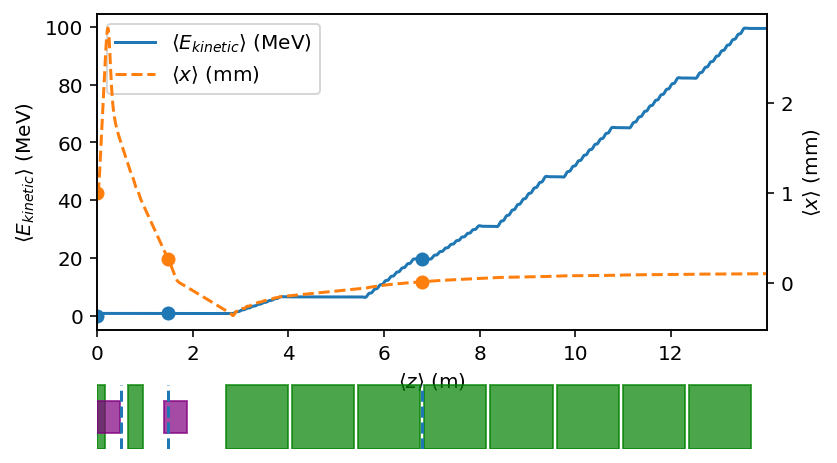

In [15]:
P0 = single_particle(pz=1e-9, x=1e-3)

I = Impact(initial_particles=P0)
stop_ele = I.lattice.pop(-1)
I.lattice.pop(1) # Remove the drift
I.input['lattice'] =  [timestep_ele] + I.lattice + deepcopy(lat) + [stop_ele]

# Make a list of s
for s in [1.490, 6.8]:
    ele = new_write_beam(s=s, ref_eles=I.lattice) # ref_eles will ensure that there are no naming conflicts
    I.add_ele(ele)


#I.lattice.insert(1, gun)
#I.lattice.insert(2, sol1)
I.input['fieldmaps'].update(FIELDMAPS)

I.ele_bookkeeper()

I.header['Dt'] = 5e-13

I.ele['stop_1']['s'] = ZSTOP
I.header['Bcurr'] = 0 # Turn off SC
I.verbose=False
I.run()
I.plot('mean_kinetic_energy', y2='mean_x')

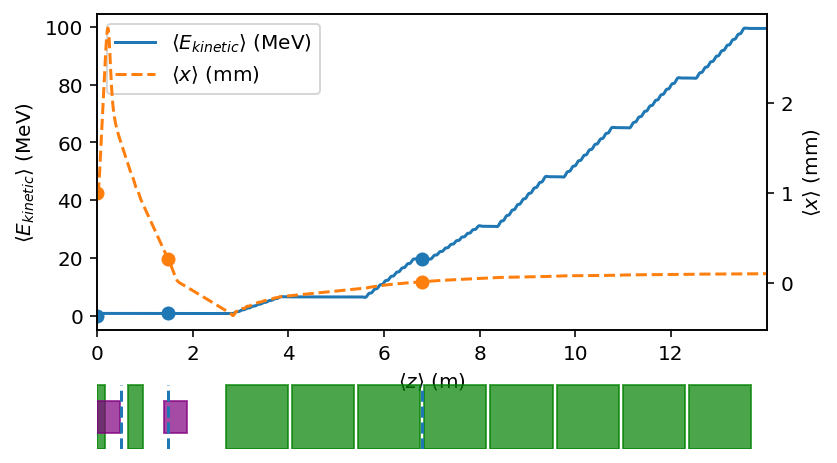

In [16]:
OUTPATH = os.path.expandvars('$LCLS_LATTICE/impact/models/sc_inj/v1')
Iout = I.copy()
Iout.header['Flagerr'] = 1 # Allow offsets
Iout.header['Flagimg'] = 1
Iout.header['Zimage'] = 0.12 # Conservative image charge distance
Iout.header['Nemission'] = 900 # for cathode start
Iout.write_input(path=OUTPATH)
Iout.track1(x0=1e-3)
Iout.plot('mean_kinetic_energy', y2='mean_x')

In [17]:
!cat {OUTPATH}/ImpactT.in

! Impact-T input file
!Npcol Nprow
1 1
!Dt Ntstep Nbunch
5e-13 1000000 1
!Dim Np Flagmap Flagerr Flagdiag Flagimg Zimage
6 1 1 1 2 1 0.12
!Nx Ny Nz Flagbc Xrad Yrad Perdlen
32 32 32 1 0.015 0.015 45.0
!Flagdist Rstartflg Flagsbstp Nemission Temission
16 0 0 900 3.372134870829164e-26
!sigx(m) sigpx muxpx xscale pxscale xmu1(m) xmu2
0.001 0.0 0.0 1.0 1.0 0.0 0.0
!sigy(m) sigpy muxpy yscale pyscale ymu1(m) ymu2
0.001 0.0 0.0 1.0 1.0 0.0 0.0
!sigz(m) sigpz muxpz zscale pzscale zmu1(m) zmu2
0.0001 0.0 0.0 1.0 1.0 0.0 0
!Bcurr Bkenergy Bmass Bcharge Bfreq Tini
0.0 1.0 510998.95 -1.0 1000000000.0 -1.686067435414582e-26
!=================== LATTICE ===================
0 0 0 -4 0.0 0.0 0.5 4e-12 /!name:change_timestep_1
0 0 0 -5 0.0 0.0 -1000.0 /!name:2d_to_3d_spacecharge
0.175 0 0 105 0.0 20000000.0 185714285.714286 179.91966462707128 1 0.15 0.0 0.0 0.0 0.0 0.0 0 /!name:RFGUNB
0.48 0 0 105 0.006530000000000036 0 0 0 2 0.15 0.0 0.0 0.0 0.0 0.0 0.0559 /!name:SOL1B
0.3 0 0 105 0.6591159999999999 

# Phase scan

Text(0.5, 1.0, '280.0')

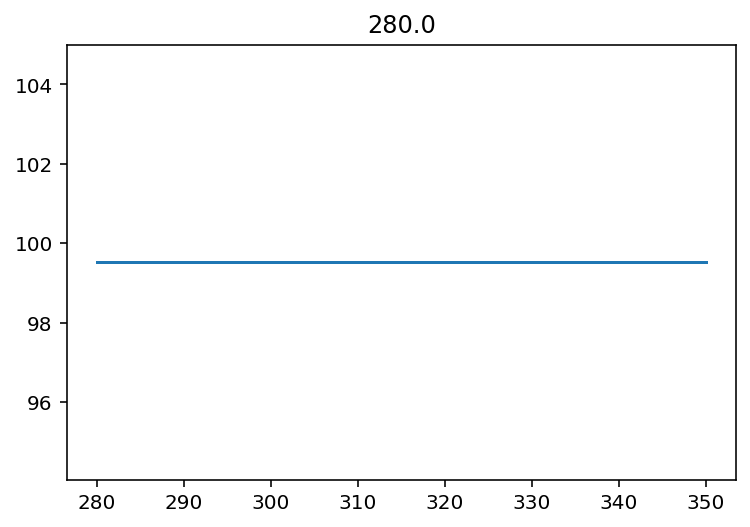

In [18]:
plist = np.linspace(280, 350, 16)
xlist = []
ylist = []

Itest = I.copy()
for p in plist:
    Itest.ele['BUN1B']['theta0_deg'] = p
    Itest.track1(x0=0)
    if 'particles' in Itest.output:
        Pf = Itest.particles['final_particles']
        x = Pf['mean_kinetic_energy']
        y = Pf['mean_z']
    else:
        x=0
        y=0
    xlist.append(x)
    ylist.append(y)
    
xlist = np.array(xlist)
ylist = np.array(ylist)
plt.plot(plist, xlist/1e6)
plt.title(f'{plist[xlist.argmax()]}')

# Check tracking

In [19]:
from pytao import Tao
from pytao.misc.markers import make_markers
from pmd_beamphysics import ParticleGroup
import pandas as pd
import numpy as np
import os


P0FILE = 'test.h5'
P0.write(P0FILE)

In [20]:
LATFILE = 'lat.bmad'
MARKERFILE = 'markers.bmad'

slist = np.linspace(0, ZSTOP, 150)
make_markers(slist, filename=MARKERFILE);

LAT = f"""
call, file = $LCLS_LATTICE/bmad/models/sc_inj/sc_inj.lat.bmad
call, file = {MARKERFILE}
"""

with open(LATFILE, 'w') as f:
    f.write(LAT)

In [21]:
%%time
tao = Tao(INIT + f' -lat {LATFILE}')
tao.cmd(f'set beam_init position_file = {P0FILE}')
tao.cmd('beamon')

CPU times: user 46.7 s, sys: 626 ms, total: 47.3 s
Wall time: 47.2 s


[]

In [22]:
ix = tao.lat_list('marker::*', 'ele.ix_ele')
df = pd.DataFrame(map(tao.bunch_params, ix))

PG1 = [ ParticleGroup(data=tao.bunch_data(i)) for i in ix]
len(PG1)

169

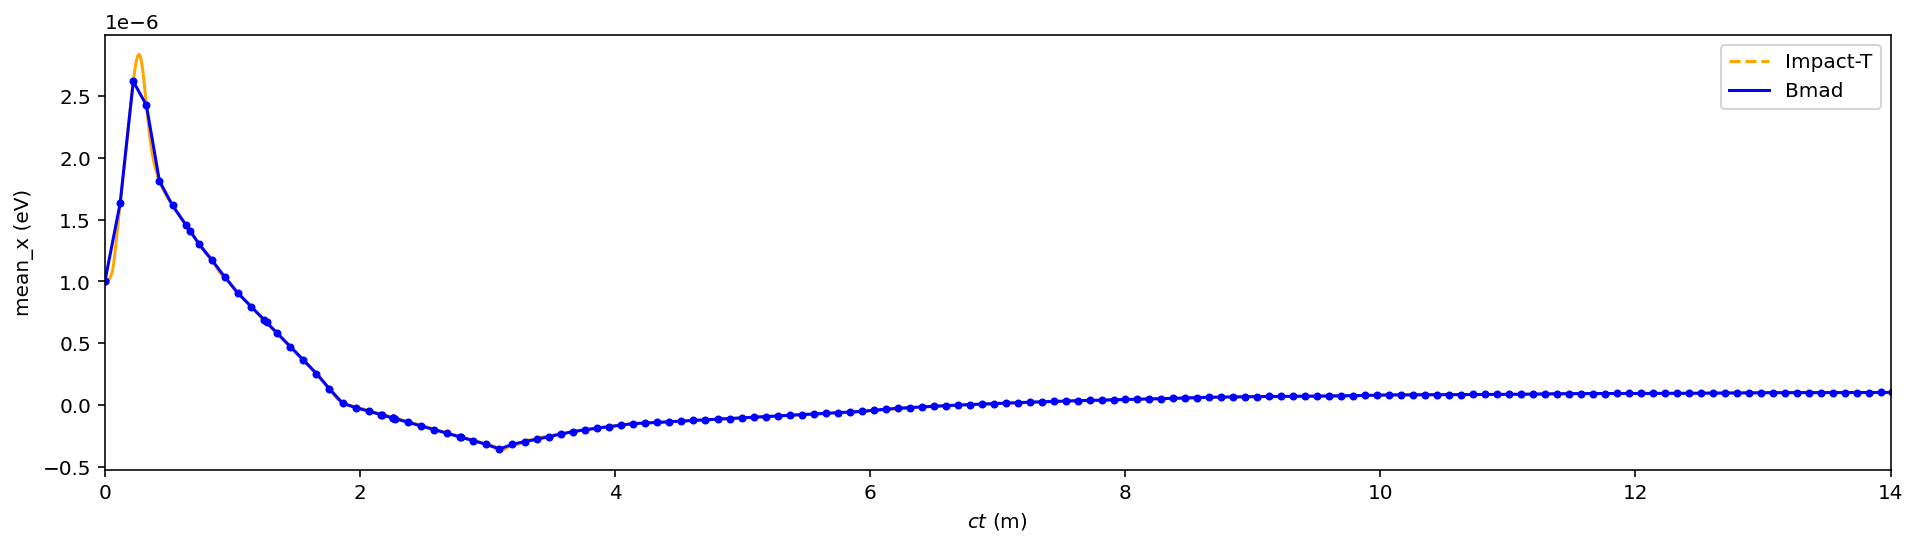

In [23]:
# Traces can be made by gathering the coordinate arrays

from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(16,4))

ykey = 'mean_x'
yscale = 1e-3
#yunit = r'µm'
yunit = 'eV'
ylabel = f'{ykey} ({yunit})'

# ax.plot(
#     [P.t*299792458 for P in  A.particles],
#     [P[ykey]*yscale for P in  A.particles], color='red', linestyle='--', marker='.',
# )

ax.plot(
     I.stat('t')*299792458,
    I.stat(ykey)*yscale,
    color='orange'
)
    

ax.plot(
    [P.t*299792458 for P in  PG1],
    [P[ykey]*yscale  for P in  PG1], color='blue', label='Bmad', marker='.',
)

ax.set_xlim(0, ZSTOP)
#ax.set_ylim(0.5e6, 2e6)

custom_lines = [Line2D([0], [0], color='orange', linestyle='--'),
                Line2D([0], [0], color='blue')]
ax.legend(custom_lines, ['Impact-T', 'Bmad'])

ax.set_xlabel(f'$ct$ (m)')
ax.set_ylabel(ylabel)
#ax.set_ylim(0, 1200)
#plt.title('Astra (red), Bmad (Blue) with fine Astra fieldmap')
plt.savefig('sc_inj-Bmad-Impact-comparison.png', bbox_inches='tight', dpi=150)

# Check phasing

In [24]:
def Ez(ele, z=0, t_or_z=0):
    return list(map(float, tao.em_field(ele, 0, 0, z, t_or_z)[0].split(';') ))[-1]

In [25]:
#tao.cmd('python em_field BUN1B|model 0 0 0 0')

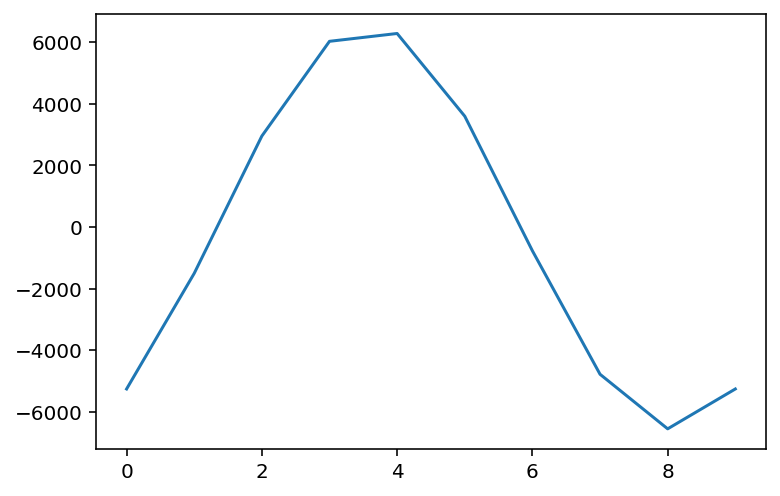

In [26]:
tlist = np.linspace(0, 1/(1.3e9), 10)
fields = [Ez('BUN1B', 0, t) for t in tlist]
plt.plot(fields)

In [27]:
# ele = 'BUN1B'
# 
# freq = 1.3e9
# tlist = np.linspace(0, 1/freq, 1000)
# fields = np.array([Ez(ele, 0, t) for t in tlist])
# fields /= fields.max()
# 
# #phi0 from Tao
# phi0_tao = 4.4003401E-02
# 
# # Get ref_time_start
# ref_time_start = tao.ele_param(ele, 'ele.ref_time_start')['ele_ref_time_start']
# phi0_ref = freq*ref_time_start
# 
# phi0_tot = (-phi0_ref + phi0_tao) %1
# 
# ft  = freq*tlist
# 
# presumed = np.cos(2*np.pi*(ft  + (phi0_tot)))
# plt.plot(360*ft, presumed, label='presumed Bmad', marker='.')
# 
# plt.plot(360*ft, fields, label='em_field_calc')
# plt.legend()
# plt.xlabel('global phase (deg)')
# plt.ylabel(f'scaled field from {ele}')